# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Tech Layoffs Highrings Dataset](https://www.kaggle.com/datasets/amaymishra11/tech-layoffs-and-hiring-trends-2026)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('tech_layoffs_hiring_trends_elite_v2.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market


## last Five row

In [4]:
df.tail()

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
11995,T11995,Anthropic,Gaming,USA,Enterprise,Mar,2024,766,8.4,Market Slowdown,...,Moderate Hiring,15.8,Software Engineer,18.5,-16.8,-0.8,4.0,6.7,5.1,Bull Market
11996,T11996,Intel,Cybersecurity,Canada,Mid-size,Jul,2026,3407,13.9,Restructuring,...,Hiring Freeze,51.8,Cloud Engineer,75.3,9.7,-1.7,2.3,7.7,6.2,Stable
11997,T11997,Netflix,Social Media,USA,Big Tech,Sep,2025,2576,8.7,Market Slowdown,...,Moderate Hiring,88.8,DevOps Engineer,40.9,11.1,10.7,7.0,8.0,5.1,Recession
11998,T11998,Salesforce,Gaming,Germany,Big Tech,Sep,2025,1039,9.1,Overhiring Correction,...,Moderate Hiring,37.6,Cybersecurity Analyst,24.2,44.2,27.4,8.9,7.3,6.2,Bull Market
11999,T11999,Databricks,AI,Germany,Big Tech,Mar,2026,493,6.6,Restructuring,...,Moderate Hiring,32.6,ML Engineer,45.1,-9.3,-7.2,2.9,4.9,6.0,Bull Market


## Shape of our dataset

In [5]:
df.shape

(12000, 23)

## List out all columns

In [6]:
df.columns

Index(['record_id', 'company_name', 'industry', 'country', 'company_size',
       'month', 'year', 'layoffs_count', 'layoff_percentage',
       'reason_for_layoffs', 'ai_automation_impact', 'ai_replacement_risk',
       'open_roles', 'hiring_trend', 'remote_jobs_percentage',
       'top_hiring_role', 'stock_growth_percent', 'revenue_growth_percent',
       'salary_budget_change', 'ai_adoption_level', 'employee_sentiment',
       'job_security_score', 'market_condition'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

record_id                  object
company_name               object
industry                   object
country                    object
company_size               object
month                      object
year                        int64
layoffs_count               int64
layoff_percentage         float64
reason_for_layoffs         object
ai_automation_impact      float64
ai_replacement_risk       float64
open_roles                  int64
hiring_trend               object
remote_jobs_percentage    float64
top_hiring_role            object
stock_growth_percent      float64
revenue_growth_percent    float64
salary_budget_change      float64
ai_adoption_level         float64
employee_sentiment        float64
job_security_score        float64
market_condition           object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               12000 non-null  object 
 1   company_name            12000 non-null  object 
 2   industry                12000 non-null  object 
 3   country                 12000 non-null  object 
 4   company_size            12000 non-null  object 
 5   month                   12000 non-null  object 
 6   year                    12000 non-null  int64  
 7   layoffs_count           12000 non-null  int64  
 8   layoff_percentage       12000 non-null  float64
 9   reason_for_layoffs      12000 non-null  object 
 10  ai_automation_impact    12000 non-null  float64
 11  ai_replacement_risk     12000 non-null  float64
 12  open_roles              12000 non-null  int64  
 13  hiring_trend            12000 non-null  object 
 14  remote_jobs_percentage  12000 non-null

## Check Null Value

In [9]:
df.isnull().sum()

record_id                 0
company_name              0
industry                  0
country                   0
company_size              0
month                     0
year                      0
layoffs_count             0
layoff_percentage         0
reason_for_layoffs        0
ai_automation_impact      0
ai_replacement_risk       0
open_roles                0
hiring_trend              0
remote_jobs_percentage    0
top_hiring_role           0
stock_growth_percent      0
revenue_growth_percent    0
salary_budget_change      0
ai_adoption_level         0
employee_sentiment        0
job_security_score        0
market_condition          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,year,layoffs_count,layoff_percentage,ai_automation_impact,ai_replacement_risk,open_roles,remote_jobs_percentage,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2024.998750,5009.572083,12.780125,6.376983,7.208758,2884.395000,50.205150,22.466550,17.469175,5.920392,5.538750,6.496217,5.805033
std,0.817703,5159.360491,10.212612,3.544012,2.677148,2149.615907,23.299575,38.814405,24.359448,11.777264,2.583047,1.582356,1.649677
min,2024.000000,0.000000,0.000000,0.600000,1.000000,52.000000,10.000000,-45.000000,-25.000000,-28.000000,1.000000,1.300000,1.000000
25%,2024.000000,1369.500000,5.100000,3.500000,5.100000,1151.000000,29.800000,-11.200000,-3.500000,-2.700000,3.300000,5.400000,4.700000
50%,2025.000000,2733.000000,9.400000,5.900000,7.600000,2282.000000,50.500000,22.600000,17.500000,5.900000,5.600000,6.500000,5.900000
75%,2026.000000,6490.000000,17.300000,8.800000,10.000000,4432.250000,70.700000,55.700000,38.400000,14.600000,7.700000,7.600000,7.000000
max,2026.000000,19999.000000,40.000000,16.800000,10.000000,9997.000000,90.000000,90.000000,60.000000,38.200000,10.000000,10.000000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

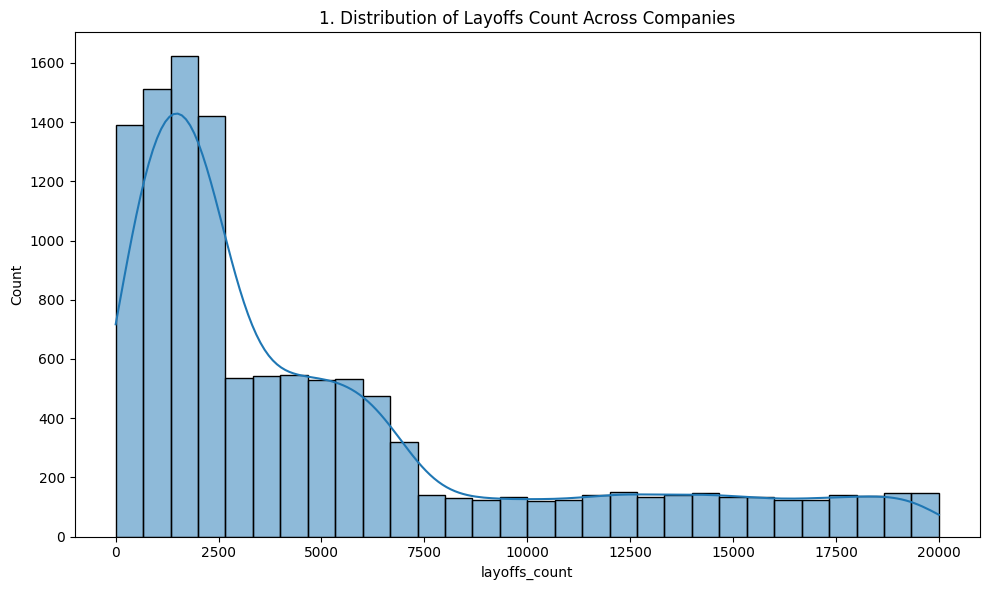

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['layoffs_count'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Layoffs Count Across Companies')
show_fig()
plot_no += 1

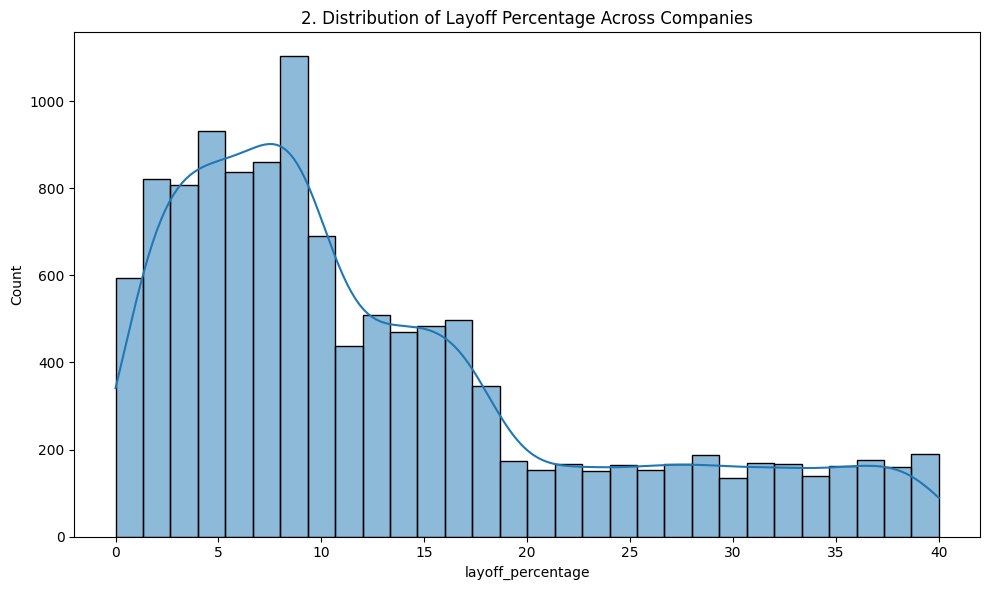

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['layoff_percentage'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Layoff Percentage Across Companies')
show_fig()
plot_no += 1

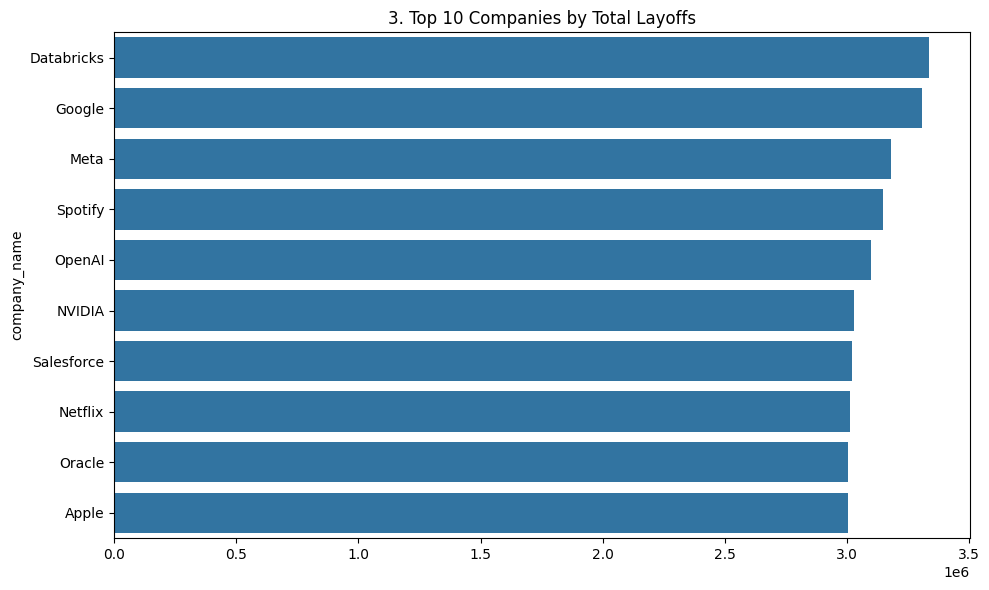

In [15]:
fig = plt.figure(figsize=(10,6))
top_companies = df.groupby('company_name')['layoffs_count'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title(f'{plot_no}. Top 10 Companies by Total Layoffs')
show_fig()
plot_no += 1

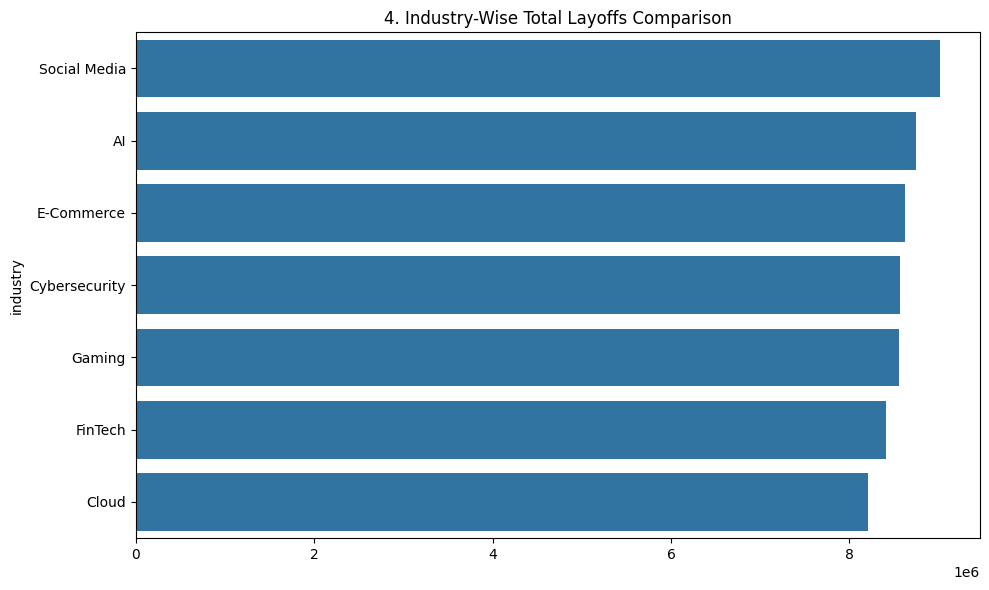

In [16]:
fig = plt.figure(figsize=(10,6))
industry_layoffs = df.groupby('industry')['layoffs_count'].sum().sort_values(ascending=False)
sns.barplot(x=industry_layoffs.values, y=industry_layoffs.index)
plt.title(f'{plot_no}. Industry-Wise Total Layoffs Comparison')
show_fig()
plot_no += 1

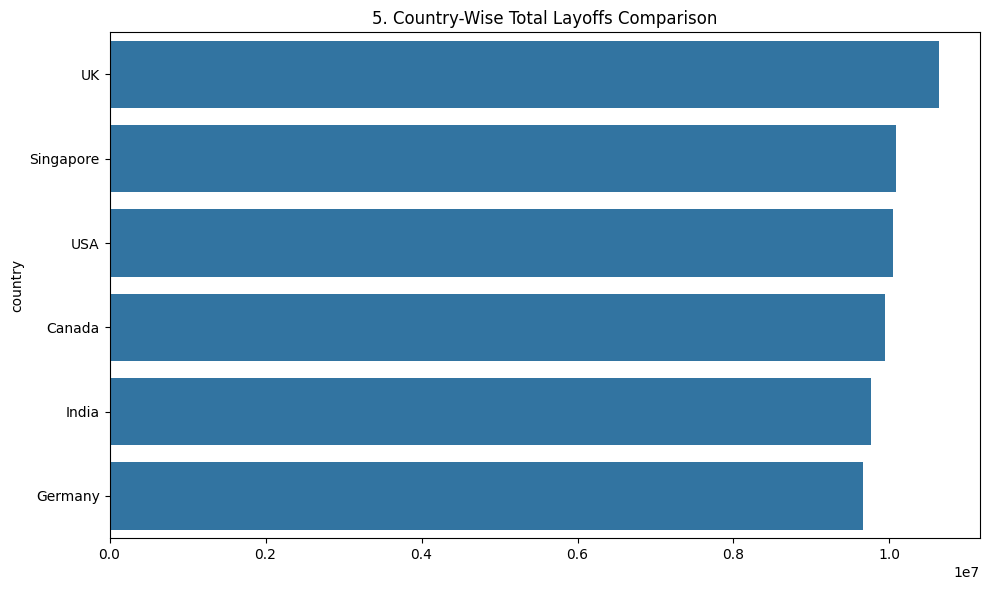

In [17]:
fig = plt.figure(figsize=(10,6))
country_layoffs = df.groupby('country')['layoffs_count'].sum().sort_values(ascending=False)
sns.barplot(x=country_layoffs.values, y=country_layoffs.index)
plt.title(f'{plot_no}. Country-Wise Total Layoffs Comparison')
show_fig()
plot_no += 1

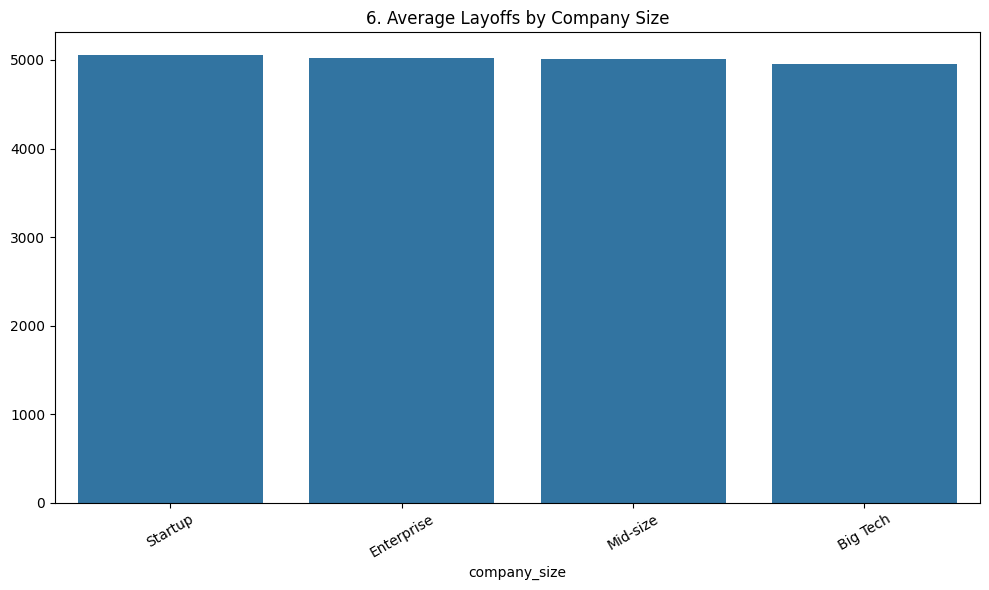

In [18]:
fig = plt.figure(figsize=(10,6))
size_layoffs = df.groupby('company_size')['layoffs_count'].mean().sort_values(ascending=False)
sns.barplot(x=size_layoffs.index, y=size_layoffs.values)
plt.title(f'{plot_no}. Average Layoffs by Company Size')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

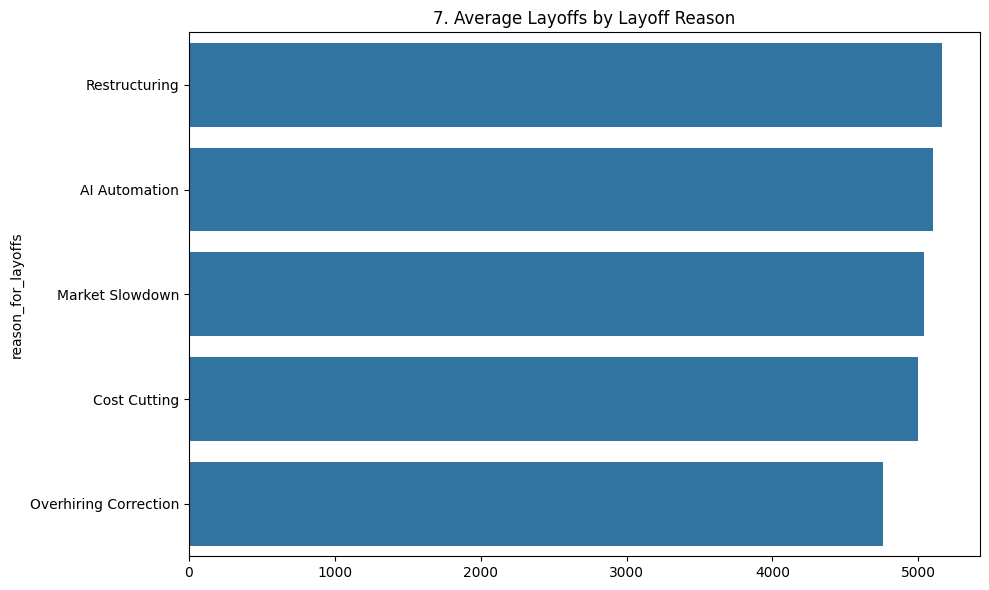

In [19]:
fig = plt.figure(figsize=(10,6))
reason_layoffs = df.groupby('reason_for_layoffs')['layoffs_count'].mean().sort_values(ascending=False)
sns.barplot(x=reason_layoffs.values, y=reason_layoffs.index)
plt.title(f'{plot_no}. Average Layoffs by Layoff Reason')
show_fig()
plot_no += 1

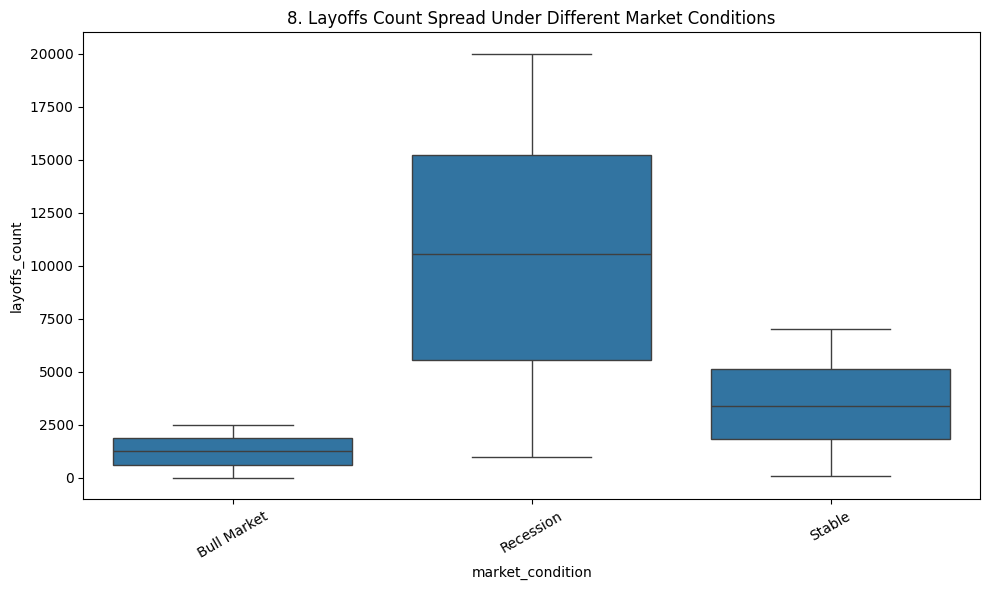

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='market_condition', y='layoffs_count')
plt.title(f'{plot_no}. Layoffs Count Spread Under Different Market Conditions')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

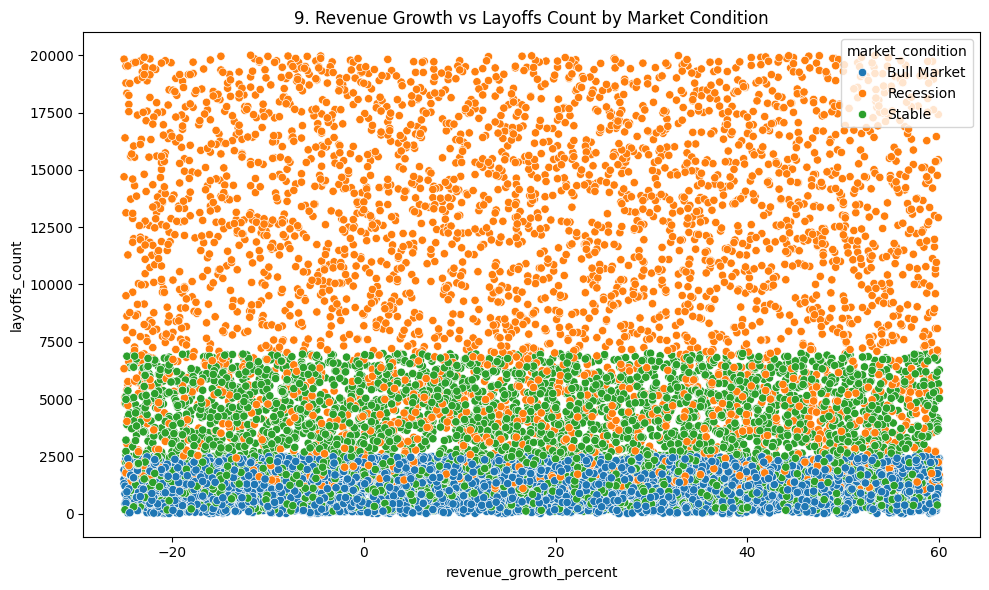

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='revenue_growth_percent', y='layoffs_count', hue='market_condition')
plt.title(f'{plot_no}. Revenue Growth vs Layoffs Count by Market Condition')
show_fig()
plot_no += 1

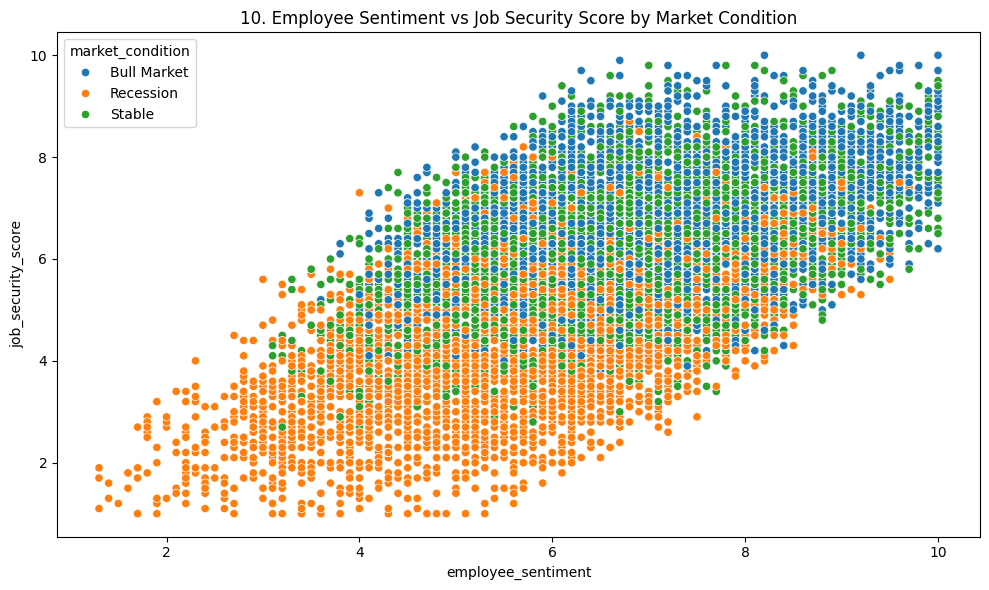

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='employee_sentiment', y='job_security_score', hue='market_condition')
plt.title(f'{plot_no}. Employee Sentiment vs Job Security Score by Market Condition')
show_fig()
plot_no += 1

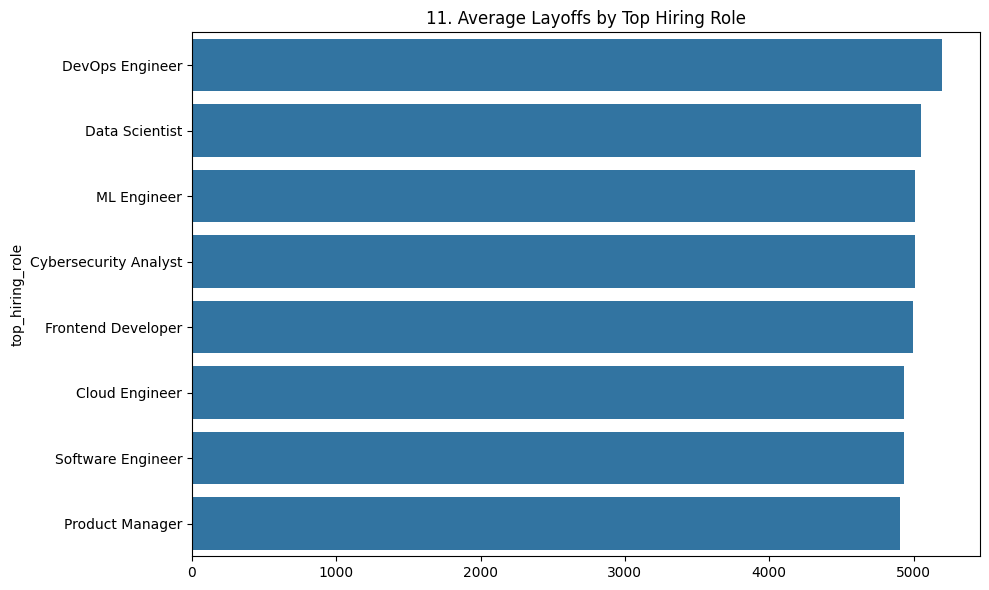

In [23]:
fig = plt.figure(figsize=(10,6))
role_layoffs = df.groupby('top_hiring_role')['layoffs_count'].mean().sort_values(ascending=False)
sns.barplot(x=role_layoffs.values, y=role_layoffs.index)
plt.title(f'{plot_no}. Average Layoffs by Top Hiring Role')
show_fig()
plot_no += 1

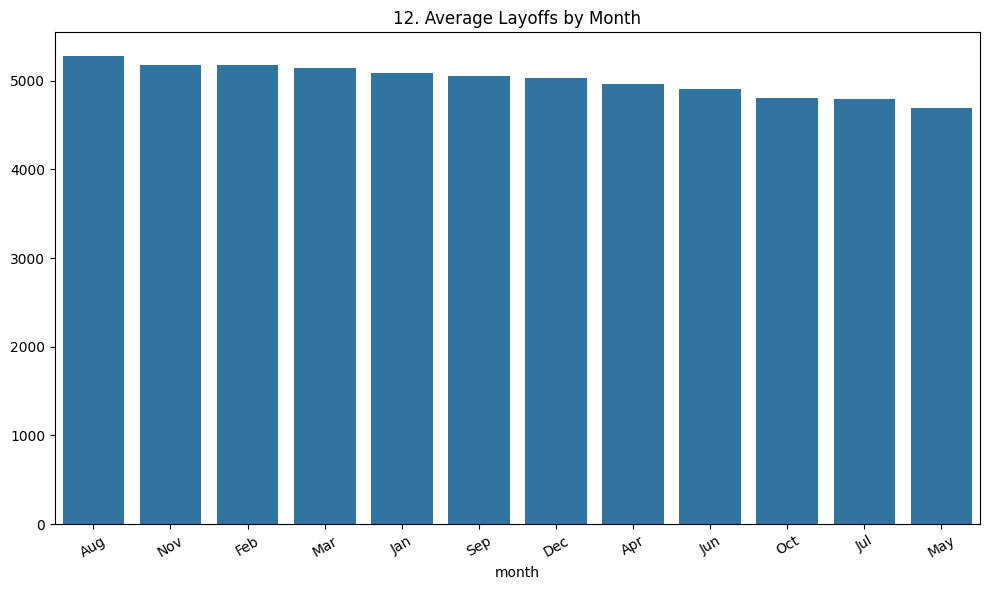

In [24]:
fig = plt.figure(figsize=(10,6))
monthly_layoffs = df.groupby('month')['layoffs_count'].mean().sort_values(ascending=False)
sns.barplot(x=monthly_layoffs.index, y=monthly_layoffs.values)
plt.title(f'{plot_no}. Average Layoffs by Month')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

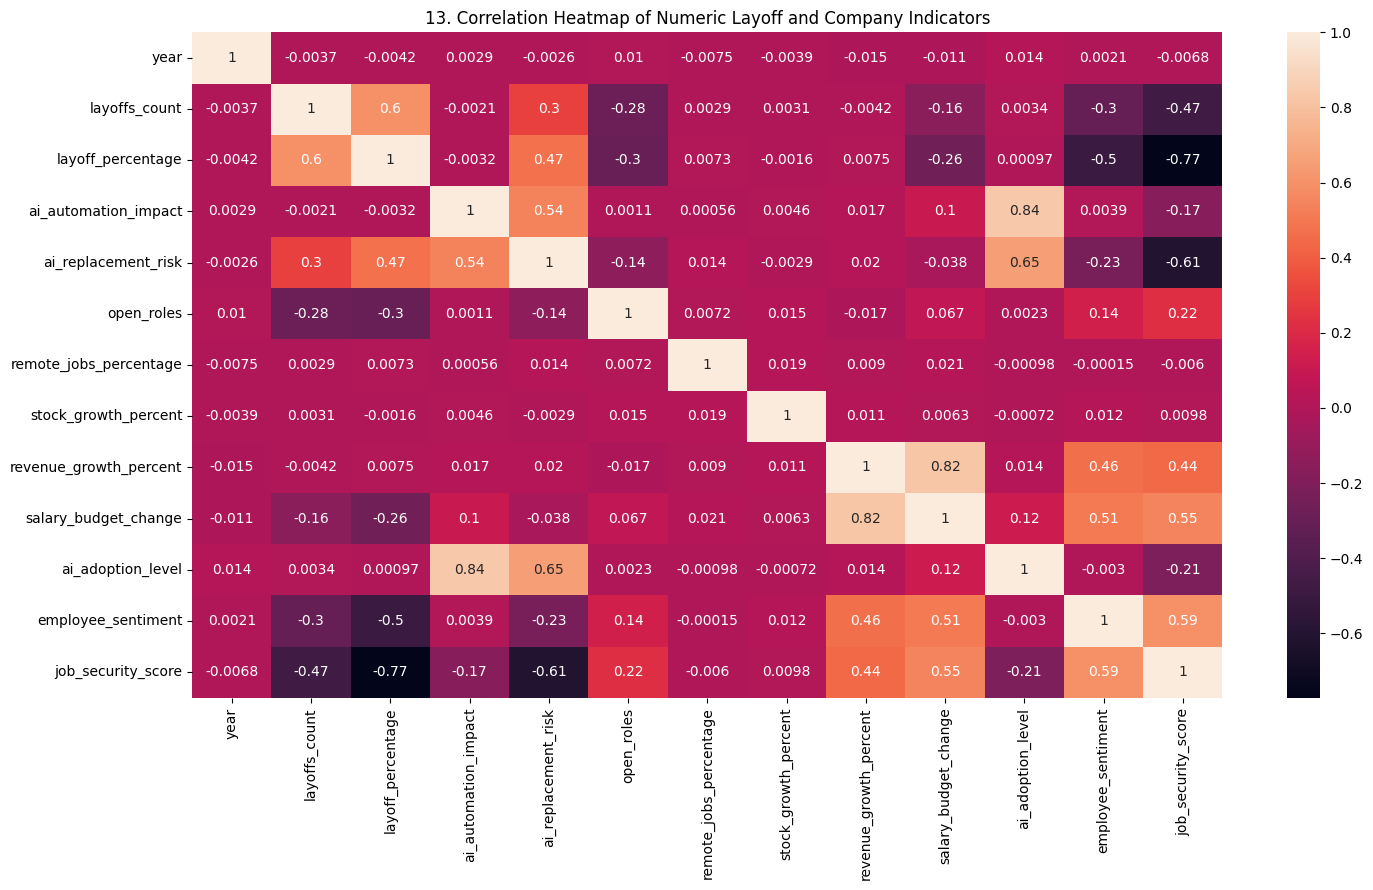

In [25]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Layoff and Company Indicators')
show_fig()
plot_no += 1

# Model Training

## Select target column

In [26]:
target = "market_condition"

## Remove unnecessary ID columns if available

In [27]:
drop_cols = ["record_id"]
drop_cols = [col for col in drop_cols if col in df.columns]

## Create X and y

In [28]:
X = df.drop(columns=[target] + drop_cols)
y = df[target]

## Separate numeric and categorical columns

In [29]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

## Create preprocessing with scaling and encoding

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Create Gradient Boosting model

In [31]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

## Split data into train and test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train model

In [33]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [34]:
y_pred = model.predict(X_test)

## Print accuracy score

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.9020833333333333


## Print classification report

In [36]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

 Bull Market       0.83      1.00      0.91       804
   Recession       0.98      0.92      0.95       781
      Stable       0.92      0.79      0.85       815

    accuracy                           0.90      2400
   macro avg       0.91      0.90      0.90      2400
weighted avg       0.91      0.90      0.90      2400



## Plot confusion matrix

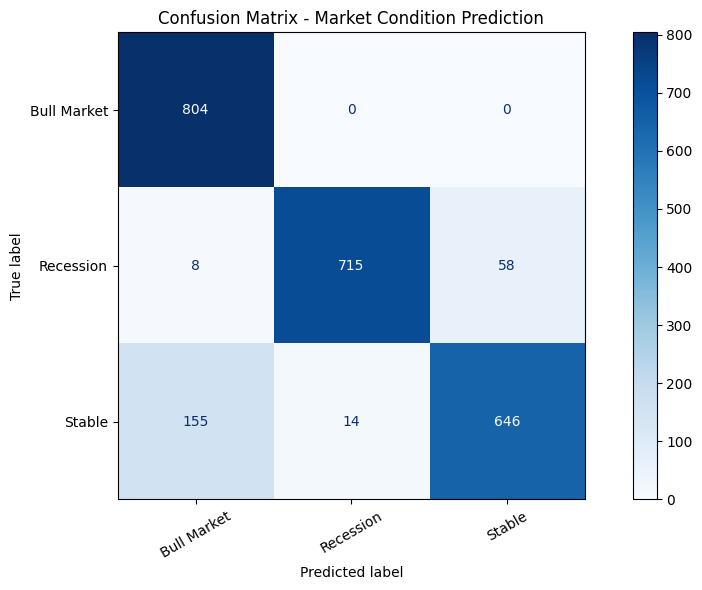

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig = plt.figure(figsize=(10,6))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix - Market Condition Prediction")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()